# WiniCari 02 Preprocessing: GPS Trip Reconstruction

**Goal:** turn raw GPS pings (`Historique_pos`) into **reconstructed trips with a derived
actual arrival time per stop** — the shared foundation for Delay prediction (labels),
Anomaly detection and GPS Fallback.

**Why derive it:** `service` / `session_ouverte` only log when a driver *opens* a run. The
arrival at the terminus, the turnaround, and the **return trip are never logged** (a driver
typically opens one service for the whole day, `voyages` empty). So trips can only be
recovered from the **GPS track**.


In [16]:
from pathlib import Path
import sys
sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data.db import get_db
from src.data import foundation as fdn

db_winicari = get_db("winicari")
db_gps = get_db("Historique_pos")

CFG = fdn.Config()         
CFG

Config(min_anchors=4, min_pings=300, first_usable_day='d20220601', dedup_round=6, signal_gap_s=600, proj_window=3, proj_gap_reset_s=900, smooth_window=15, reversal_frac=0.15, reversal_floor_m=2000.0, min_span_frac=0.06, min_span_floor_m=1500.0, min_trip_min=8.0, layover_gap_s=2400, park_frac=0.05, full_frac=0.1, arrival_thresh_m=350.0)

## Line geometry — keep geocoded anchors, drop placeholders

`array_lat/lng_opendata` maps one coordinate per stop, but many stops are stored as `0.0`
(not geocoded). We keep the geocoded **anchors** in route order and skip the rest — partial
coverage, not a reason to drop a line. `code` is **not unique across companies**, so we key
everything by `(code, societe)`.

In [17]:
# One query builds {(code, societe) -> anchor stops with cumulative route distance}
USABLE = fdn.build_usable_lines(db_winicari, CFG)

n_zero = sum(len(fdn.real_anchor_stops(ligne)) == 0
             for ligne in db_winicari["ligne"].find({}, {"array_lat_opendata": 1,
                                                          "array_lng_opendata": 1}))
print(f"usable (code, societe) lines: {len(USABLE)} | lines with 0 geocoded stops: {n_zero}")
USABLE[("209", "S.R.T.K")].head()

usable (code, societe) lines: 135 | lines with 0 geocoded stops: 249


,seq,route_seq,name,lat,lon,s_m
0,0,0,KASSERINE,35.178056,8.847499,0.000000
1,1,1,BOUZGUEM,35.209142,8.894370,5485.235148
2,2,2,EL GARRAA,35.228854,8.960128,11848.232621
3,3,3,CHRAYA,35.255313,9.022020,18192.423815
4,4,4,SBEITLA,35.231061,9.130617,28416.628099


## Stop geometry audit — how complete is the network?

For every line we count: total stops declared, geocoded (real lat/lon), missing (stored as `0.0`).
We classify each line into one of five types:

| type | meaning |
|---|---|
| `full` | every stop geocoded |
| `partial` | some stops geocoded, some missing |
| `terminal_only` | only 1–2 stops geocoded (usually just origin + terminus) |
| `no_geometry` | stops declared but none geocoded |
| `no_stops` | no stop array at all in the config |

Lines classified `terminal_only` are the ones you suspected: route_km is just a straight-line
distance between the two endpoints — **not** the actual road distance.

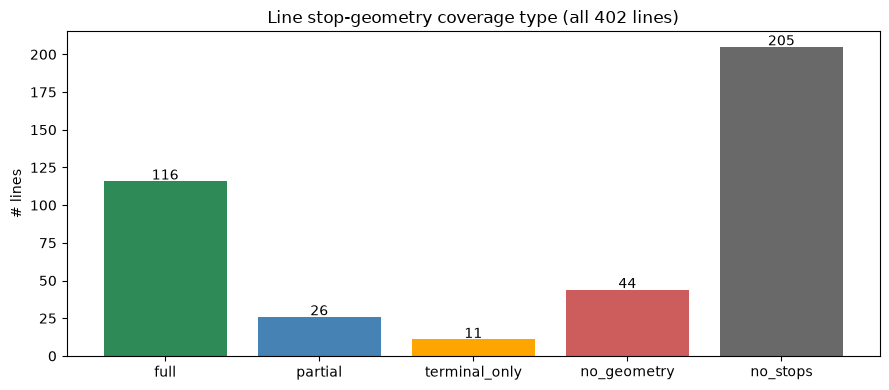

coverage_type
full             116
partial           26
terminal_only     11
no_geometry       44
no_stops         205

Total lines: 402  |  with any geometry: 153  |  blind (0 geocoded): 249


In [18]:
from pathlib import Path
import numpy as np

LD = Path(fdn.__file__).resolve().parents[2] / "data" / "processed" / "line_distances.parquet"
ld = pd.read_parquet(LD)

#cCoverage type breakdown
ct = ld["coverage_type"].value_counts().reindex(
    ["full", "partial", "terminal_only", "no_geometry", "no_stops"])

plt.figure(figsize=(9, 4))
colors = ["seagreen", "steelblue", "orange", "indianred", "dimgrey"]
bars = plt.bar(ct.index, ct.values, color=colors)
for b, v in zip(bars, ct.values):
    plt.text(b.get_x() + b.get_width()/2, v + 1, str(v), ha="center", fontsize=10)
plt.ylabel("# lines"); plt.title("Line stop-geometry coverage type (all 402 lines)")
plt.tight_layout(); plt.show()

print(ct.to_string())
print(f"\nTotal lines: {len(ld)}  |  with any geometry: {(ld['geocoded_stops']>0).sum()}  "
      f"|  blind (0 geocoded): {(ld['geocoded_stops']==0).sum()}")

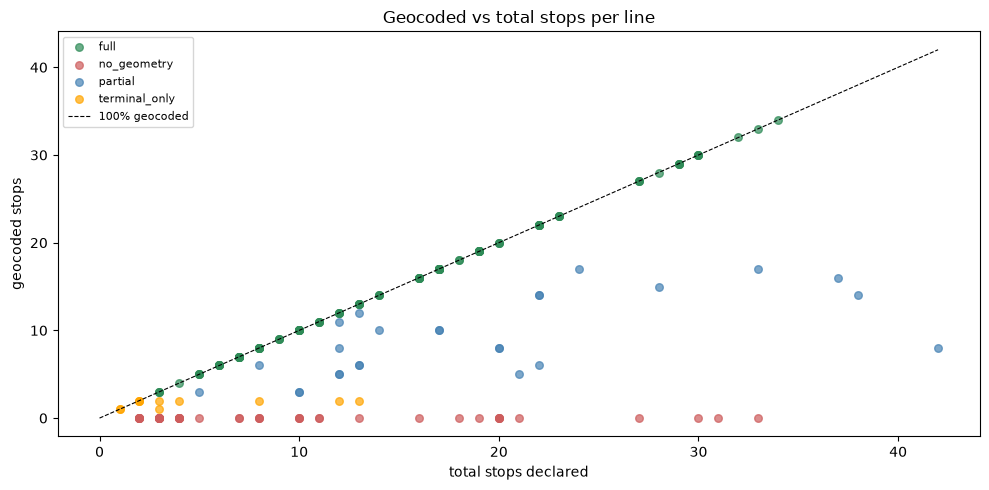

In [19]:
# Missing vs geocoded stops per line 
has_stops = ld[ld["total_stops"] > 0].copy()
cmap = {"full":"seagreen","partial":"steelblue","terminal_only":"orange",
        "no_geometry":"indianred","no_stops":"dimgrey"}

plt.figure(figsize=(10, 5))
for ct_type, grp in has_stops.groupby("coverage_type"):
    plt.scatter(grp["total_stops"], grp["geocoded_stops"],
                label=ct_type, color=cmap.get(ct_type,"grey"), alpha=0.7, s=30)
plt.plot([0, has_stops["total_stops"].max()],
         [0, has_stops["total_stops"].max()],
         "k--", lw=0.8, label="100% geocoded")
plt.xlabel("total stops declared"); plt.ylabel("geocoded stops")
plt.title("Geocoded vs total stops per line")
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

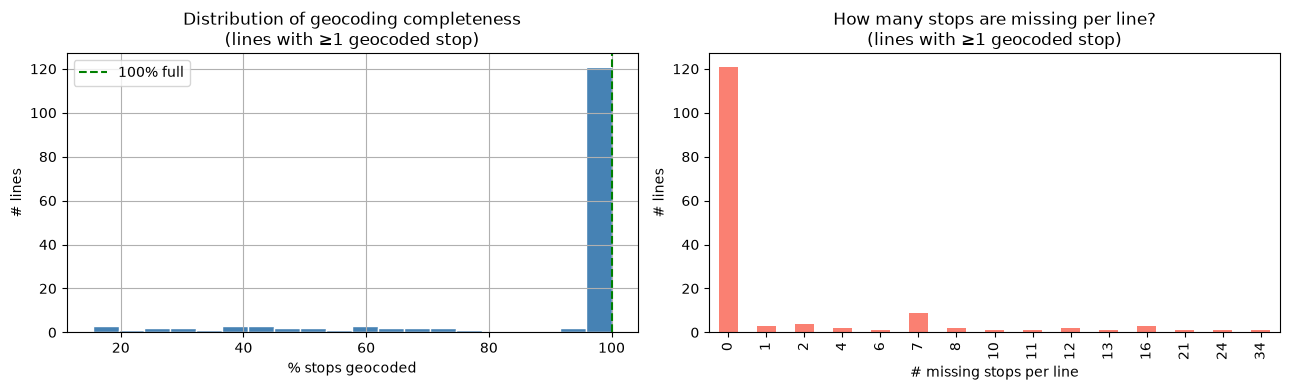

In [20]:
# % geocoded distribution — how cut are the partial lines?
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

has_geo = ld[ld["geocoded_stops"] > 0]
has_geo["pct_geocoded"].hist(bins=20, ax=ax[0], color="steelblue", edgecolor="white")
ax[0].axvline(100, color="green", ls="--", label="100% full")
ax[0].set_xlabel("% stops geocoded"); ax[0].set_ylabel("# lines")
ax[0].set_title("Distribution of geocoding completeness\n(lines with ≥1 geocoded stop)")
ax[0].legend()

# missing stops per line (for lines that have some geometry)
has_geo["missing_stops"].value_counts().sort_index().head(20).plot(kind="bar", ax=ax[1], color="salmon")
ax[1].set_xlabel("# missing stops per line"); ax[1].set_ylabel("# lines")
ax[1].set_title("How many stops are missing per line?\n(lines with ≥1 geocoded stop)")
plt.tight_layout(); plt.show()

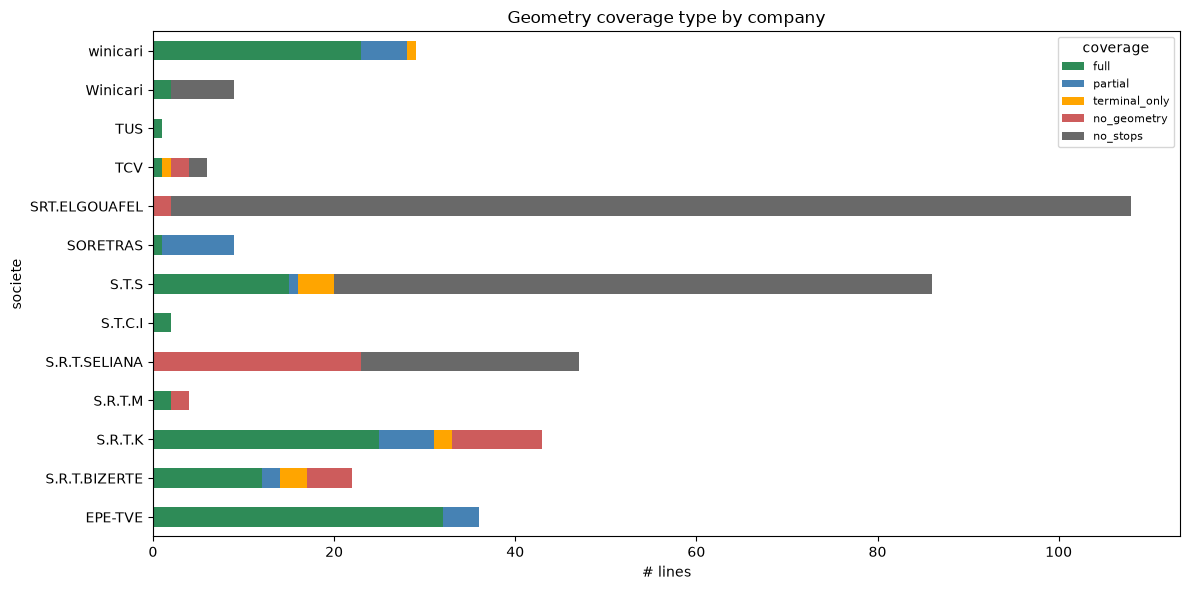


Terminal-only lines (11) — route_km is straight-line origin→terminus only:
    line        societe  total_stops  geocoded_stops  missing_stops  route_km
16   116  S.R.T.BIZERTE            2               2              0    41.394
17   103  S.R.T.BIZERTE            2               2              0    54.452
30   102  S.R.T.BIZERTE            2               2              0    55.852
98   220          S.T.S           12               2             10    25.675
99   221          S.T.S            4               2              2   244.970
102  224          S.T.S           13               2             11     2.102
159  213          S.T.S            8               2              6    10.585
161  999        S.R.T.K            1               1              0     0.000
190  999       winicari            1               1              0     0.000
217  105        S.R.T.K            3               2              1     5.485
229    1            TCV            3               1              

In [21]:
# By company: coverage type stacked bar 
order = ["full", "partial", "terminal_only", "no_geometry", "no_stops"]
colors = {"full":"seagreen","partial":"steelblue","terminal_only":"orange",
          "no_geometry":"indianred","no_stops":"dimgrey"}

pivot = (ld.groupby(["societe","coverage_type"]).size()
           .unstack(fill_value=0)
           .reindex(columns=order, fill_value=0))

pivot.plot(kind="barh", stacked=True, figsize=(12, 6),
           color=[colors[c] for c in order])
plt.xlabel("# lines"); plt.title("Geometry coverage type by company")
plt.legend(title="coverage", bbox_to_anchor=(1,1), fontsize=8)
plt.tight_layout(); plt.show()

# terminal-only lines listed explicitly
show_cols = [c for c in ["line","societe","total_stops","geocoded_stops","missing_stops","route_km"] if c in ld.columns]
term = ld[ld["coverage_type"]=="terminal_only"][show_cols]
print(f"\nTerminal-only lines ({len(term)}) — route_km is straight-line origin→terminus only:")
print(term.to_string())

### What this means for the pipeline

- **`full` (116 lines):** all stops geocoded → route_km is accurate, match rate should be high.
- **`partial` (26 lines):** gaps in the middle → route_km underestimates (missing hops); match rate will be lower for missing stops. The pipeline skips `0.0` placeholders and uses the remaining anchors.
- **`terminal_only` (11 lines):** only origin + terminus geocoded → route_km is a **straight-line crow-flies distance**, shorter than the real road. The pipeline treats these as 2-anchor lines; `min_anchors=4` means they are **not usable** for trip reconstruction.
- **`no_geometry` (44 lines):** stops declared but coordinates all `0.0` → pipeline rejects them entirely.
- **`no_stops` (205 lines):** no stop array at all → most are SRT.ELGOUAFEL and S.R.T.SELIANA. Pipeline cannot use them. The only fix is for those companies to geocode their stops.

## 1. Load + clean one bus-day

`load_pings` normalizes the schema drift (`localisation.x=lat`, `.y=lon`; speed = top-level
`speed` else `bus.vitesse`). `clean_pings` drops consecutive stationary duplicates (~10%)
and flags signal gaps. We fix one clean intercity example for reproducibility.

In [22]:
# Show all stops for a given line with their coordinates, cumulative distance, and ordered geometry
LINE, SOCIETE = "209", "S.R.T.K"
stops = USABLE[(LINE, SOCIETE)]

# Add distance between consecutive stops for reference
stops_display = stops.copy()
stops_display["distance_to_next_km"] = 0.0
for i in range(len(stops_display) - 1):
    stops_display.loc[i, "distance_to_next_km"] = (
        (stops_display.loc[i+1, "s_m"] - stops_display.loc[i, "s_m"]) / 1000
    )

# Format and display
display_cols = ["seq", "name", "lat", "lon", "s_m", "distance_to_next_km"]
stops_summary = stops_display[display_cols].copy()
stops_summary["s_m"] = (stops_summary["s_m"] / 1000).round(2)  # convert to km
stops_summary["distance_to_next_km"] = stops_summary["distance_to_next_km"].round(2)
stops_summary.columns = ["Stop #", "Stop Name", "Latitude", "Longitude", "Cumulative Distance (km)", "Distance to Next Stop (km)"]

print(f"\n{LINE} {SOCIETE} — All {len(stops)} Stops in Route Order")
print("="*120)
display(stops_summary)

# Summary statistics
total_distance = stops["s_m"].max() / 1000
print(f"\nTotal route distance: {total_distance:.1f} km | Average stop spacing: {total_distance / len(stops):.2f} km")


209 S.R.T.K — All 22 Stops in Route Order


,Stop #,Stop Name,Latitude,Longitude,Cumulative Distance (km),Distance to Next Stop (km)
0,0,KASSERINE,35.178056,8.847499,0.00,5.49
1,1,BOUZGUEM,35.209142,8.894370,5.49,6.36
2,2,EL GARRAA,35.228854,8.960128,11.85,6.34
3,3,CHRAYA,35.255313,9.022020,18.19,10.22
4,4,SBEITLA,35.231061,9.130617,28.42,7.72
5,5,OUED ELMIOU,35.207744,9.210719,36.14,7.09
6,6,ESSABALA,35.177449,9.279409,43.23,8.21
7,7,EL BLAKAT,35.147836,9.362125,51.44,7.88
8,8,M'AMMER,35.121844,9.442698,59.32,8.88
9,9,BLAK BOUZID,35.099726,9.536530,68.20,11.39



Total route distance: 192.0 km | Average stop spacing: 8.73 km


In [23]:
LINE, SOCIETE, BUS, DAY = "209", "S.R.T.K", 6030, "d20260615"
stops = USABLE[(LINE, SOCIETE)]

raw = fdn.load_pings(db_gps, DAY, LINE, BUS)
g = fdn.clean_pings(raw, CFG)
print(f"line {LINE} {SOCIETE} bus {BUS} {DAY[1:]} | stops={len(stops)}")
print(f"raw pings {len(raw)} -> cleaned {len(g)} (removed {len(raw)-len(g)} stationary, "
      f"{100*(len(raw)-len(g))//len(raw)}%) | median interval {g['gap_s'].median():.0f}s "
      f"| signal gaps {int(g['signal_gap'].sum())} | largest {g['gap_s'].max():.0f}s")
g.head()

line 209 S.R.T.K bus 6030 20260615 | stops=22
raw pings 4023 -> cleaned 3582 (removed 441 stationary, 10%) | median interval 5s | signal gaps 4 | largest 3607s


,t,lat,lon,speed,gap_s,signal_gap
0,2026-06-15 09:51:43.431,35.177807,8.847803,0.00000,NaN,False
1,2026-06-15 09:53:08.483,35.177807,8.847807,0.00000,85.052,False
2,2026-06-15 09:53:18.483,35.177807,8.847805,0.14816,10.000,False
3,2026-06-15 09:53:58.500,35.177807,8.847807,0.00000,40.017,False
4,2026-06-15 09:54:58.518,35.177807,8.847805,0.00000,60.018,False


## 2. Map-match each ping to a route distance

`project_to_route` does a **sequential (windowed) projection** onto the anchor polyline,
giving a smooth distance-along-route `s` (and off-route `off_m`). The windowing keeps `s`
physically smooth despite sparse anchors — the key to clean segmentation.

route length (anchor polyline): 192 km | mean off-route distance: 336 m


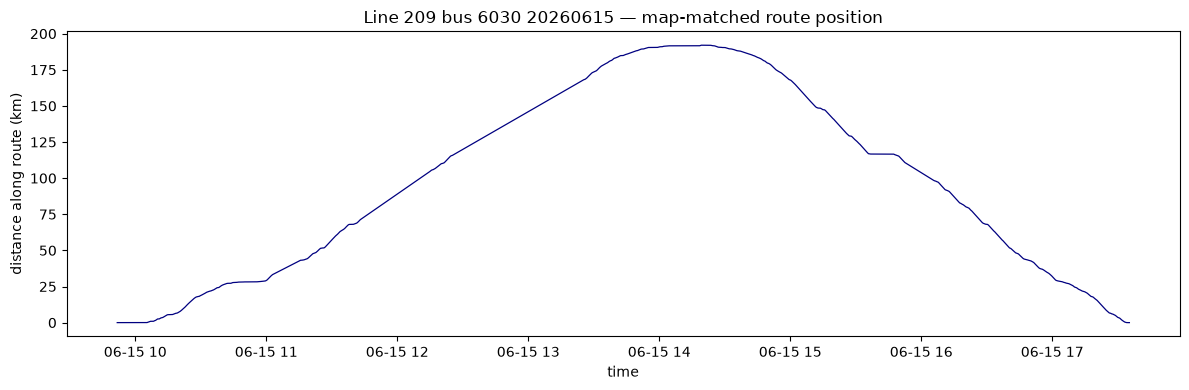

In [24]:
g, route_len = fdn.project_to_route(g, stops, CFG)
print(f"route length (anchor polyline): {route_len/1000:.0f} km | "
      f"mean off-route distance: {g['off_m'].mean():.0f} m")

plt.figure(figsize=(12, 4))
plt.plot(g["t"], g["s"] / 1000, linewidth=0.9, color="navy")
plt.ylabel("distance along route (km)"); plt.xlabel("time")
plt.title(f"Line {LINE} bus {BUS} {DAY[1:]} — map-matched route position")
plt.tight_layout(); plt.show()

## 3. Segment trips — full **and** partial

`segment_trips` detects **direction swings** (turnarounds) using a scale-invariant
hysteresis (fraction of route length), so it works for a 200 km intercity line and a 6 km
urban loop alike. It splits a same-direction run **only** at a *parked* layover gap (big
time gap where the bus barely moved) — so a mid-route signal gap does **not** fragment one
run, and a bus that turns back early is kept as a **partial** trip.

detected 2 trips (2 full, 0 partial)
      dir  full  start    end     km
0   ALLER  True  09:51  14:19  192.0
1  RETOUR  True  14:19  17:35  192.0


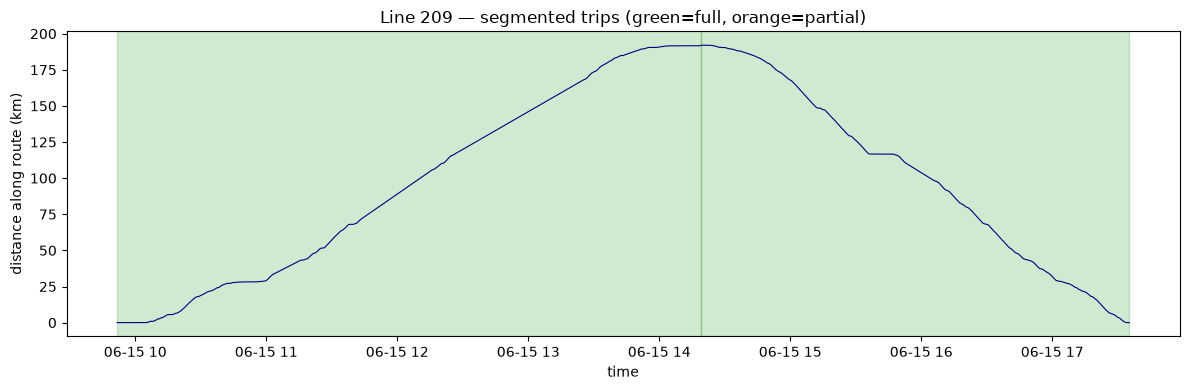

In [25]:
trips = fdn.segment_trips(g, route_len, CFG)
view = trips.assign(start=trips["start"].dt.strftime("%H:%M"),
                    end=trips["end"].dt.strftime("%H:%M"),
                    km=((trips["s_hi"] - trips["s_lo"]) / 1000).round(1))[
    ["dir", "full", "start", "end", "km"]]
print(f"detected {len(trips)} trips ({trips['full'].sum()} full, {(~trips['full']).sum()} partial)")
print(view.to_string())

plt.figure(figsize=(12, 4))
plt.plot(g["t"], g["s"] / 1000, linewidth=0.8, color="navy")
for _, tr in trips.iterrows():
    plt.axvspan(tr["start"], tr["end"], alpha=0.18,
                color="green" if tr["full"] else "orange")
plt.ylabel("distance along route (km)"); plt.xlabel("time")
plt.title(f"Line {LINE} — segmented trips (green=full, orange=partial)")
plt.tight_layout(); plt.show()



## 4. Derive actual arrival time per stop

### The Problem in Simple Terms
Imagine you have a bus and a GPS device on it that records its location every 5 seconds. But the **database does NOT store when the bus arrived at each stop** — only the raw GPS positions.

Your job: **figure out what time the bus actually arrived at each stop** by looking at the GPS track.

### Example Walkthrough

Let's say a bus stops at KASSERINE, BOUZGUEM, and SFAX (in that order).

**Step 1: What we know**
```
STOPS on the route:
├─ Stop 0: KASSERINE    at coordinates (35.178, 8.847)
├─ Stop 1: BOUZGUEM    at coordinates (35.209, 8.894)
└─ Stop 2: SFAX        at coordinates (34.722, 10.757)

GPS PINGS from the bus (every 5 seconds):
├─ 09:54:30  at (35.177, 8.847)  ← GPS is RIGHT at KASSERINE, but is this the arrival?
├─ 09:55:18  at (35.178, 8.847)  ← GPS is RIGHT at KASSERINE again
├─ 09:55:25  at (35.177, 8.848)  ← still very close to KASSERINE
├─ 10:05:32  at (35.178, 8.848)  ← still at KASSERINE (parked, waiting)
├─ 10:14:53  at (35.209, 8.894)  ← GPS jumps to BOUZGUEM (bus started moving)
├─ 10:17:23  at (35.210, 8.895)  ← still at BOUZGUEM
├─ ... (many pings) ...
└─ 14:19:16  at (34.722, 10.757) ← arrived at SFAX
```

**Step 2: Match each stop to its first ping** (within 350 meters)
```
For KASSERINE (35.178, 8.847):
  ✓ 09:54:30 is 100m away    ← FIRST match, use this
  ✓ 09:55:18 is 50m away     ← skip, later ping
  ✓ 09:55:25 is 80m away     ← skip, later ping
  ✓ 10:05:32 is 90m away     ← skip, later ping

For BOUZGUEM (35.209, 8.894):
  ✓ 10:14:53 is 30m away     ← FIRST match, use this

For SFAX (34.722, 10.757):
  ✓ 14:19:16 is 50m away     ← FIRST match, use this
```

**Step 3: Find when the bus LEFT each stop**
```
When did the bus leave KASSERINE?
  ← Look for the first ping AFTER the arrival that is NOT at KASSERINE
  ← The ping at 10:14:53 moved to BOUZGUEM coordinates
  → The bus left KASSERINE and arrived at BOUZGUEM at 10:14:53

So:
  Arrival at KASSERINE:  09:54:30
  Departure from KASSERINE: 10:14:53  (which is also arrival at BOUZGUEM)
  Dwell time at KASSERINE: 10:14:53 - 09:54:30 = 20 minutes 23 seconds
```

### The Result Table

| Stop | Stop Name | Arrival | Departure | Dwell (min) | Matched |
|------|-----------|---------|-----------|-------------|---------|
| 0 | KASSERINE | 09:54:30 | 10:14:53 | 20.4 | ✓ |
| 1 | BOUZGUEM | 10:14:53 | 10:17:23 | 2.5 | ✓ |
| 2 | SFAX | 14:19:16 | 14:19:16 | 0.0 | ✓ |

---

### Real-World Edge Cases

**What if a stop is NOT found?**
```
Stop: EL FAIDH at coordinates (35.057, 9.650)
GPS pings nearest to EL FAIDH: all are more than 350m away

Result:
├─ Arrival: NaN (null/missing)
├─ Departure: NaN
├─ Dwell: NaN
└─ Matched: ✗ (False)

Why? 
→ Stop coordinates might be wrong
→ GPS had a gap and missed this stop
→ Bus actually skipped this stop
```

**What if the bus parks for a long time at one stop?**
```
GPS pings at KASSERINE:
├─ 09:54:30  (lat=35.178, lon=8.847)  ← ARRIVAL
├─ 09:55:00  (lat=35.178, lon=8.847)  ← still here, parked
├─ 09:56:00  (lat=35.178, lon=8.847)  ← still here, parked
├─ 10:05:00  (lat=35.178, lon=8.847)  ← still here, parked
├─ 10:14:53  (lat=35.209, lon=8.894)  ← DEPARTURE (moved to next stop)

Result:
├─ Arrival: 09:54:30
├─ Departure: 10:14:53
└─ Dwell: 20 minutes 23 seconds ✓ (passenger boarding time)
```

---

### Summary
`derive_arrivals` is a **snapping algorithm** that:
1. ✓ Finds the **closest GPS ping** for each stop (within 350m)
2. ✓ Records the **time of that ping** as the arrival time
3. ✓ Calculates **how long the bus stayed** at each stop
4. ✗ Marks stops that **couldn't be found** as unmatched

This creates the **arrival/departure times** that were missing from the raw database.

In [ ]:
# Show the state of the data right before arrival derivation
tr = trips.iloc[0]
seg_pings = g[(g["t"] >= tr["start"]) & (g["t"] <= tr["end"])].copy()

print(f"Trip {tr['dir']}: {tr['start']} to {tr['end']}")
print(f"Pings in this trip: {len(seg_pings)}")
print(f"\nBefore derive_arrivals — raw pings with map-matched route position:")
print(seg_pings[["t", "s", "off_m", "speed"]].head(20).to_string())

# Show the covered range of the route
print(f"\nTrip covers route from {seg_pings['s'].min()/1000:.1f} km to {seg_pings['s'].max()/1000:.1f} km")
print(f"Number of stops in this range: {((stops['s_m'] >= seg_pings['s'].min()) & (stops['s_m'] <= seg_pings['s'].max())).sum()}")

# Show what stops the bus is supposed to visit during this trip
trip_stops = stops[(stops["s_m"] >= seg_pings["s"].min()) & (stops["s_m"] <= seg_pings["s"].max())][["seq", "name", "s_m"]]
print(f"\nStops the bus should visit in order:")
print(trip_stops.assign(s_m_km=trip_stops["s_m"]/1000).to_string())

Trip ALLER: 2026-06-15 09:51:43.431000 to 2026-06-15 14:19:16.612000
Pings in this trip: 1594

Before derive_arrivals — raw pings with map-matched route position:
                         t         s      off_m    speed
0  2026-06-15 09:51:43.431  4.262433  39.065166  0.00000
1  2026-06-15 09:53:08.483  4.263020  39.256371  0.00000
2  2026-06-15 09:53:18.483  4.263020  39.160769  0.14816
3  2026-06-15 09:53:58.500  4.263020  39.256371  0.00000
4  2026-06-15 09:54:58.518  4.321303  39.160769  0.00000
5  2026-06-15 09:55:18.519  4.379586  39.016620  0.00000
6  2026-06-15 09:55:48.536  4.497326  39.112222  0.00000
7  2026-06-15 09:56:18.552  4.615066  39.303427  0.27780
8  2026-06-15 09:56:23.552  5.321505  39.877043  0.37040
9  2026-06-15 09:56:33.552  5.555811  39.828497  0.00000
10 2026-06-15 09:56:38.553  5.790117  39.779950  0.18520
11 2026-06-15 09:56:43.553  6.142162  39.827006  0.18520
12 2026-06-15 09:56:48.553  6.378816  39.921118  0.25928
13 2026-06-15 09:57:03.554  6.378816  4

In [27]:
tr = trips.iloc[0]
arr = fdn.derive_arrivals(g, tr, stops, CFG)
print(f"Trip 0 ({tr['dir']}, full={tr['full']}): matched {arr['matched'].sum()}/{len(arr)} "
      f"covered stops ({arr['matched'].mean():.0%})")
arr.assign(arrival=arr["arrival"].dt.strftime("%H:%M:%S"))

Trip 0 (ALLER, full=True): matched 13/22 covered stops (59%)


,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,0,0,KASSERINE,09:55:18,2026-06-15 10:05:32.434,613.9,39,True
1,1,1,BOUZGUEM,10:14:53,2026-06-15 10:17:23.494,150.0,6,True
2,2,2,EL GARRAA,10:23:27,2026-06-15 10:23:37.524,10.0,136,True
3,3,3,CHRAYA,10:29:17,2026-06-15 10:29:32.632,15.0,20,True
4,4,4,SBEITLA,10:57:40,2026-06-15 10:58:55.358,75.1,113,True
5,5,5,OUED ELMIOU,NaN,NaT,NaN,2927,False
6,6,6,ESSABALA,11:16:22,2026-06-15 11:17:27.498,65.0,38,True
7,7,7,EL BLAKAT,11:24:52,2026-06-15 11:26:27.676,95.0,35,True
8,8,8,M'AMMER,11:31:17,2026-06-15 11:31:27.735,10.0,12,True
9,9,9,BLAK BOUZID,11:40:09,2026-06-15 11:40:44.413,35.0,1,True


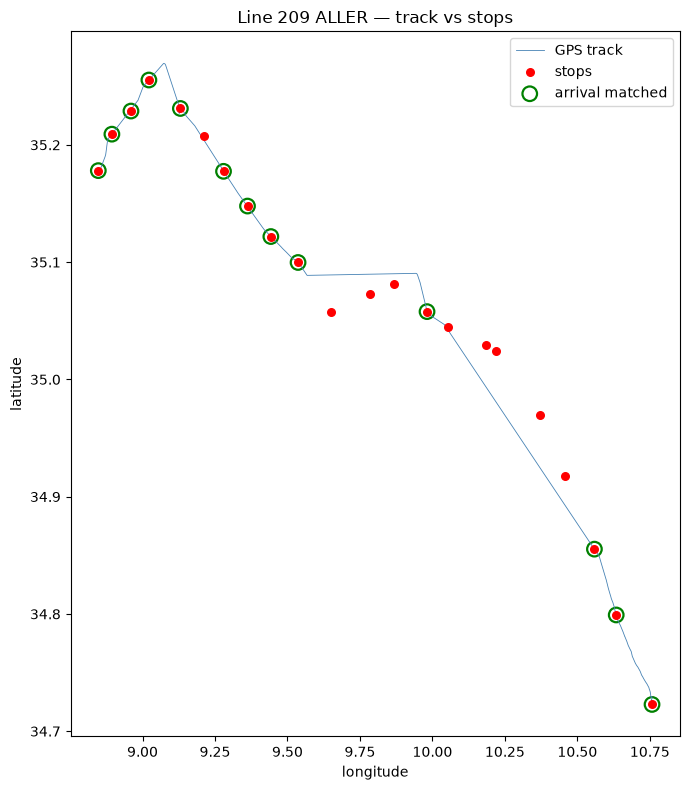

In [28]:
# Map view: route stops + the bus track + matched arrivals for trip 0
seg = g[(g["t"] >= tr["start"]) & (g["t"] <= tr["end"])]
matched = arr[arr["matched"]]
plt.figure(figsize=(7, 8))
plt.plot(seg["lon"], seg["lat"], linewidth=0.6, color="steelblue", label="GPS track")
plt.scatter(stops["lon"], stops["lat"], c="red", s=30, zorder=3, label="stops")
plt.scatter([stops["lon"].iloc[s] for s in matched["seq"]],
            [stops["lat"].iloc[s] for s in matched["seq"]],
            facecolors="none", edgecolors="green", s=110, linewidths=1.6, label="arrival matched")
plt.xlabel("longitude"); plt.ylabel("latitude")
plt.title(f"Line {LINE} {tr['dir']} — track vs stops"); plt.legend()
plt.tight_layout(); plt.show()

## 5. Full pipeline for one bus-day

`reconstruct_bus_day` chains all of the above and returns one row per covered stop-arrival.

In [29]:
demo = fdn.reconstruct_bus_day(db_gps, DAY, LINE, SOCIETE, BUS, stops, CFG)
print(f"rows={len(demo)} | trips={demo['trip_id'].nunique()} | "
      f"match rate={100*demo['matched'].mean():.0f}%")
print("columns:", list(demo.columns))
demo.head(12)

rows=44 | trips=2 | match rate=75%
columns: ['day', 'line', 'societe', 'bus', 'trip_id', 'dir', 'full', 'trip_start', 'trip_end', 'seq', 'route_seq', 'stop', 'arrival', 'departure', 'dwell_s', 'dist_m', 'matched']


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,0,0,KASSERINE,2026-06-15 09:55:18.519,2026-06-15 10:05:32.434,613.9,39,True
1,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,1,1,BOUZGUEM,2026-06-15 10:14:53.457,2026-06-15 10:17:23.494,150.0,6,True
2,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,2,2,EL GARRAA,2026-06-15 10:23:27.524,2026-06-15 10:23:37.524,10.0,136,True
3,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,3,3,CHRAYA,2026-06-15 10:29:17.632,2026-06-15 10:29:32.632,15.0,20,True
4,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,4,4,SBEITLA,2026-06-15 10:57:40.230,2026-06-15 10:58:55.358,75.1,113,True
5,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,5,5,OUED ELMIOU,NaT,NaT,NaN,2927,False
6,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,6,6,ESSABALA,2026-06-15 11:16:22.479,2026-06-15 11:17:27.498,65.0,38,True
7,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,7,7,EL BLAKAT,2026-06-15 11:24:52.626,2026-06-15 11:26:27.676,95.0,35,True
8,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,8,8,M'AMMER,2026-06-15 11:31:17.734,2026-06-15 11:31:27.735,10.0,12,True
9,20260615,209,S.R.T.K,6030,0,ALLER,True,2026-06-15 09:51:43.431,2026-06-15 14:19:16.612,9,9,BLAK BOUZID,2026-06-15 11:40:09.397,2026-06-15 11:40:44.413,35.0,1,True


### Why We Build the Foundation — The Big Picture

The **foundation dataset** is the **single shared source of truth** for all four AI modules. It solves a critical problem:

**The Problem:**
```
Raw data is scattered and incomplete:
├─ Ticketing database (winicari): has route definitions, stop coordinates
├─ GPS database (Historique_pos): has raw GPS pings (millions per day)
└─ Neither has explicit arrival times at stops
```

**What we need for ML:**
```
For DELAY prediction:
  ✓ Actual arrival time at each stop
  ✓ Scheduled vs actual delay labels
  ✓ Bus, line, direction, date context

For GPS FALLBACK:
  ✓ Clean GPS track with known positions
  ✓ Stop locations on the route
  ✓ Signal gaps marked

For ANOMALY detection:
  ✓ Per-trip features (dwell times, match rates)
  ✓ Trip metadata (full vs partial, company)

For RAG chatbot:
  ✓ Line statistics (coverage, match rates)
  ✓ Anomaly trip details
```

### The Foundation Dataset Structure

One row = one bus arrival at one stop

```
┌─ Identifiers ───────────────────────────────────┐
│ day: 20260615                                   │  which day
│ line: 209                                       │  which bus line
│ societe: S.R.T.K                               │  which company
│ bus: 6030                                       │  which bus vehicle
│ trip_id: 0                                      │  which trip on that day
│ dir: ALLER                                      │  direction (ALLER/RETOUR)
│ full: True                                      │  full trip or partial?
├─ Trip metadata ─────────────────────────────────┤
│ trip_start: 2026-06-15 09:51:43                │  when trip started
│ trip_end: 2026-06-15 14:19:16                  │  when trip ended
├─ Stop details ─────────────────────────────────┤
│ seq: 0                                          │  stop number along route
│ route_seq: 0                                    │  original stop position
│ stop: KASSERINE                                 │  stop name
│ arrival: 2026-06-15 09:55:18                   │  when bus arrived (from GPS match)
│ departure: 2026-06-15 10:05:32                 │  when bus left (next GPS ping)
│ dwell_s: 613.9                                  │  seconds parked at stop
├─ GPS quality metrics ──────────────────────────┤
│ dist_m: 39.0                                    │  GPS to stop distance (m)
│ matched: True                                   │  was stop successfully matched?
└─────────────────────────────────────────────────┘

Example: On 2026-06-15, bus 6030 on line 209 (S.R.T.K, direction ALLER)
arrived at KASSERINE at 09:55:18, sat for 10 minutes 14 seconds (boarding),
and left at 10:05:32. GPS was only 39m away from the stop.
```

### The Build Process

```
┌──────────────────────────────────────────────────────────────┐
│                    RAW DATA SOURCES                           │
│  ┌─────────────────┐      ┌──────────────────────────────┐  │
│  │ winicari DB     │      │ Historique_pos DB (MongoDB)  │  │
│  │ ├─ ligne        │      │ d20260601, d20260602, ...    │  │
│  │ │ ├─ code       │      │ (one collection per day)     │  │
│  │ │ ├─ arrets      │      │ Each doc:                    │  │
│  │ │ └─ societe     │      │  ├─ position.lat/lng         │  │
│  │ ├─ arrets        │      │  ├─ bus.code                 │  │
│  │ │ ├─ lat/lng     │      │  ├─ service.codeLigne        │  │
│  │ │ └─ names       │      │  └─ createdAt (timestamp)    │  │
│  │ └─ tickets       │      └──────────────────────────────┘  │
│  └─────────────────┘                                          │
└──────────────────────────────────────────────────────────────┘
                              ↓
                    [build_foundation.py]
                              ↓
    (for each usable line, for each day, for each bus)
    ┌─────────────────────────────────────────────┐
    │  1. Load GPS pings from MongoDB             │
    │  2. Clean pings (remove stationary dups)    │
    │  3. Project pings onto route geometry       │
    │  4. Segment into individual trips           │
    │  5. Snap stops to pings (derive arrival)    │
    │  6. Calculate dwell times                   │
    └─────────────────────────────────────────────┘
                              ↓
┌──────────────────────────────────────────────────────────────┐
│        OUTPUT: foundation_arrivals_full.parquet               │
│        168,481 rows × 16 columns                             │
│        covering 3,343 unique (day, line, bus) combinations   │
│        with 20,743 reconstructed trips                       │
└──────────────────────────────────────────────────────────────┘
                              ↓
    ┌──────────────────┬──────────────────┬──────────────────┐
    │   DELAY MODULE   │   GPS FALLBACK   │   ANOMALY MODULE │
    │                  │                  │                  │
    │ Uses: arrival,   │ Uses: raw GPS,   │ Uses: per-trip   │
    │ delay labels     │ stops, dwell     │ dwell, distance, │
    │ (vs schedule)    │                  │ match rates      │
    └──────────────────┴──────────────────┴──────────────────┘
```

### Key Statistics from the Built Foundation

```
foundation_arrivals_full.parquet
├─ Rows: 168,481 (one per stop arrival)
├─ Bus-days: 3,343 unique (day, line, bus) combinations
├─ Trips: 20,743 reconstructed journeys
├─ Lines: 29 distinct bus lines
├─ Date range: 2025-01-01 to 2026-06-21 (18 months)
└─ Overall stop match rate: 76%
    ├─ Well-mapped lines (e.g. 209): 85-95% match rate
    └─ Poorly-mapped lines (urban): 40-60% match rate
```

### Why This Approach?

**Instead of** building separate datasets for each module:
```
❌ Delay dataset        ❌ GPS dataset        ❌ Anomaly dataset
   └─ separate logic       └─ separate logic      └─ separate logic
   └─ inconsistent         └─ inconsistent        └─ inconsistent
   └─ hard to maintain     └─ hard to maintain    └─ hard to maintain
```

**We build ONE foundation, then slice it:**
```
✓ Single source of truth
✓ All modules use identical trip/stop definitions
✓ Changes to foundation automatically propagate
✓ Easier to maintain and debug
✓ High reusability across the project
```

### What This Enables Downstream

Once the foundation exists, building models becomes **much simpler**:

- **Delay module**: just merge foundation with scheduled times → get labels
- **GPS fallback**: foundation already has clean GPS track + stops
- **Anomaly**: foundation already has per-trip aggregates
- **RAG**: foundation has all the statistics to build knowledge base

In short: **Foundation = the 80% hard work of data preparation**. Everything else is just plugging models on top.

In [30]:
# repo root resolved from the library location -> works regardless of cwd
OUT = Path(fdn.__file__).resolve().parents[2] / "data" / "processed" / "foundation_arrivals_full.parquet"
if OUT.exists():
    fa = pd.read_parquet(OUT)
    bd = fa.groupby(["day", "line", "societe", "bus"]).ngroups
    tr_n = fa.groupby(["day", "line", "societe", "bus", "trip_id"]).ngroups
    print(f"loaded {OUT.name}: rows={len(fa)} | bus-days={bd} | trips={tr_n} "
          f"| lines={fa['line'].nunique()} | overall match={100*fa['matched'].mean():.0f}%")
    print(f"day range: {fa['day'].min()} .. {fa['day'].max()} | "
          f"full trips={fa.groupby(['day','line','bus','trip_id'])['full'].first().sum()}")
else:
    fa = pd.DataFrame()
    print(f"{OUT} not found — run the CLI above to build it.")
fa.head()

loaded foundation_arrivals_full.parquet: rows=168481 | bus-days=3343 | trips=20743 | lines=29 | overall match=76%
day range: 20250101 .. 20260621 | full trips=17341


,day,line,societe,bus,trip_id,dir,full,trip_start,trip_end,seq,route_seq,stop,arrival,departure,dwell_s,dist_m,matched
0,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,0,0,KASSERINE,2025-01-01 03:01:22.300,2025-01-01 03:04:52.262,210.0,92.0,True
1,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,1,1,BOUZGUEM,2025-01-01 03:14:07.268,2025-01-01 03:14:37.281,30.0,46.0,True
2,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,2,2,EL GARRAA,NaT,NaT,NaN,1238.0,False
3,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,3,3,CHRAYA,2025-01-01 03:24:01.335,2025-01-01 03:24:01.335,0.0,17.0,True
4,20250101,217,S.R.T.K,6036,0,ALLER,True,2025-01-01 03:00:52.299,2025-01-01 07:51:24.201,4,4,SBEITLA,2025-01-01 03:39:24.278,2025-01-01 03:39:24.278,0.0,118.0,True


bus_days  trips  stops  match_rate
societe line                                    
S.R.T.K 501          2      3      3       100.0
S.T.S   107          1     34     34       100.0
        225          3     73     73        99.0
S.R.T.K 306        144   1054   1054        95.0
S.T.S   216          7     33     33        88.0
        301         28    850    850        87.0
        306         52   2538   2538        85.0
S.R.T.K 211          5     87     87        85.0
        415          4     31     31        84.0
TCV     3          405  85412  85412        83.0
S.T.S   226         19    725    725        82.0
S.R.T.K 202        115   4749   4749        80.0
        500         10    108    108        79.0
        428          6     42     42        79.0
S.T.S   211         37   1251   1251        79.0
        101        145   6582   6582        77.0
        219         62  11732  11732        75.0
S.R.T.K 209        127   4922   4922        74.0
S.T.S   304        226  10506  10506        71.0
        541          2    122    122        70.0
S.R.T.K 217        153   7699   7699        70.0
        216         30   1413   1413        69.0
        204        116   3811   3811        68.0
        203        147   5513   5513        68.0
S.T.S   215          8     94     94        64.0
S.R.T.K 215        148   6207   6207        61.0
        205         13    129    129        61.0
        311          5     50     50        60.0
        212        280  12552  12552        55.0
        201          6    140    140        49.0
        402          1      5      5        40.0
S.T.S   515          1      9      9        11.0
S.R.T.K 424          1      1      1         0.0
S.T.S   212          1      4      4         0.0

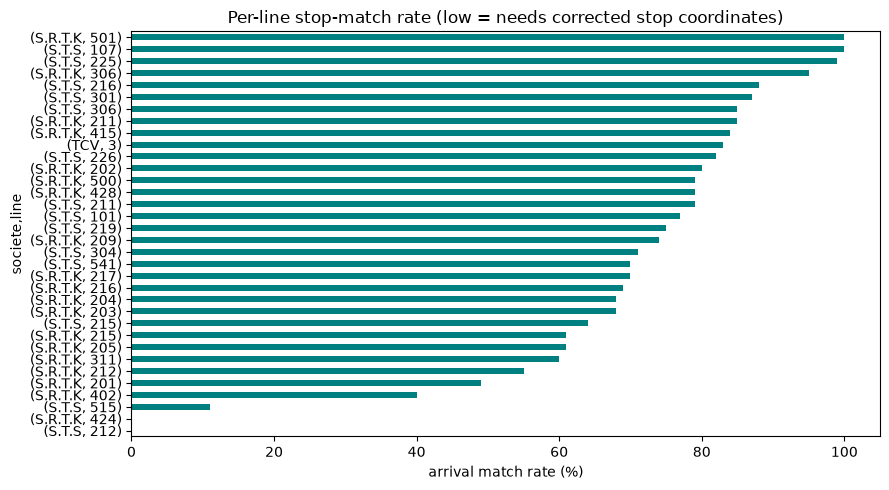

In [31]:
# Per-line match rate = headline data-quality signal (which lines have good stop coords)
if len(fa):
    per_line = (fa.groupby(["societe", "line"])
                  .agg(bus_days=("day", "nunique"), trips=("trip_id", "size"),
                       stops=("matched", "size"), match_rate=("matched", "mean"))
                  .assign(match_rate=lambda d: (100 * d["match_rate"]).round())
                  .sort_values("match_rate", ascending=False))
    display(per_line)

    ax = per_line["match_rate"].plot(kind="barh", figsize=(9, 5), color="teal")
    ax.set_xlabel("arrival match rate (%)")
    ax.set_title("Per-line stop-match rate (low = needs corrected stop coordinates)")
    ax.invert_yaxis(); plt.tight_layout(); plt.show()

### Caveats / quality notes (feed back to the audit)

- **Geometry is partial:** ~135 lines usable (>= 4 geocoded anchors); ~249 have none. Sparse
  anchors mean the polyline only approximates the road — segmentation uses distance *swings*
  with hysteresis rather than exact map-matching for robustness.
- **Match rate per line is the quality metric.** Well-mapped intercity lines score high; short
  urban lines and lines with imprecise stop coords (e.g. some S.R.T.K lines) score low and
  should get corrected coordinates from the company before they're model-ready.
- **Partial trips are kept** (bus turns back early, or day ends mid-run) and flagged via
  `full=False`; mid-route signal gaps do not fragment a run.
- **No scheduled per-stop times exist yet** to subtract — `ligne.horaires` only holds
  departure times. Delay labelling (actual − scheduled) is the next notebook once schedules
  are mapped per stop.
- All tunables live in `fdn.Config`; the same code path runs in the notebook and the CLI.